# ML Models

Logistic Regression vs. XGBoost vs. Random Forest

In [75]:
# Import for dataset
import xgboost as xgb
import pandas as pd

from sklearn.model_selection import train_test_split
#from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, average_precision_score

df = pd.read_csv('adult.csv', sep=', ', engine='python', dtype={
    "age": int,
    "workclass": 'category',
    "fnlwgt": int,
    "education": 'category',
    "education-num": int,
    "marital-status": 'category',
    "occupation": 'category',
    "relationship": 'category',
    "race": 'category',
    "sex": 'category',
    "capital-gain": int,
    "capital-loss": int,
    "hours-per-week": int,
    "native-country": 'category',
    "class": 'category'
})

#print(df)

X = df.drop('class', axis=1)
y = df['class'].map({'<=50K': 1, '>50K': 0}) # <=50K = 1 because that is good


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

## XGBoost

In [76]:
clf = xgb.XGBClassifier(tree_method='hist', random_state=420, early_stopping_rounds=10, enable_categorical=True)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

y_pred = clf.predict(X_test)

evals_result = clf.evals_result()
print(evals_result)

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, clf.predict_proba(X_test)[:, 1])

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("PR AUC:", pr_auc)

# save for later
xgb_clf = clf

{'validation_0': OrderedDict({'logloss': [0.4415823130239343, 0.389751828402743, 0.3575865246782229, 0.33696358868045484, 0.3221988369430903, 0.31170616523987155, 0.3040168656308805, 0.2987310489819527, 0.2944634196035474, 0.29106885615825473, 0.289187838970464, 0.2872335520864955, 0.2860238047618532, 0.283482839867948, 0.28308706220997126, 0.28268142286730275, 0.28232728018092657, 0.28175078494318856, 0.2811573781008567, 0.28041475013634654, 0.2798448588990489, 0.27872097334824075, 0.2783665914642877, 0.2775488075389828, 0.27748728769986475, 0.2779340648188216, 0.2772270461692787, 0.27709683310094385, 0.27666067768984054, 0.27624850533069256, 0.2762834511620956, 0.27686622452746606, 0.27711253926415225, 0.27692870869671643, 0.27660378054240636, 0.2768571705211547, 0.2764601815211708, 0.27641259708133364, 0.2758361723300545, 0.276125932015978, 0.27630530787617724, 0.27601713891457363, 0.27646593236294675, 0.2766374620494474, 0.27698640371877425, 0.27680711305776645, 0.2770493624288379,

## Logistic Regression

In [77]:
from sklearn.linear_model import LogisticRegression

dummies_X_train = pd.get_dummies(X_train.select_dtypes(include=['category']))

clf = LogisticRegression(max_iter=1000, random_state=420)
clf.fit(dummies_X_train, y_train)

dummies_X_test = pd.get_dummies(X_test.select_dtypes(include=['category']))

y_pred = clf.predict(dummies_X_test)

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, clf.predict_proba(dummies_X_test)[:, 1])

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("PR AUC:", pr_auc)

Confusion Matrix:
 [[ 835  745]
 [ 350 4583]]
Precision: 0.8601726726726727
Recall: 0.9290492600851409
F1 Score: 0.8932852548484553
PR AUC: 0.957674995584787


## Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier

# poorer performance may be due to dummies?

clf = RandomForestClassifier(random_state=420)
clf.fit(dummies_X_train, y_train)

y_pred = clf.predict(dummies_X_test)

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, clf.predict_proba(dummies_X_test)[:, 1])

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("PR AUC:", pr_auc)

Confusion Matrix:
 [[ 892  688]
 [ 445 4488]]
Precision: 0.8670788253477589
Recall: 0.9097912021082506
F1 Score: 0.8879216539717084
PR AUC: 0.943680623932719


# User Stories

## As a member of the UVW marketing team, I want to know the average importance of each measurable factor of an individual in determining their income level.

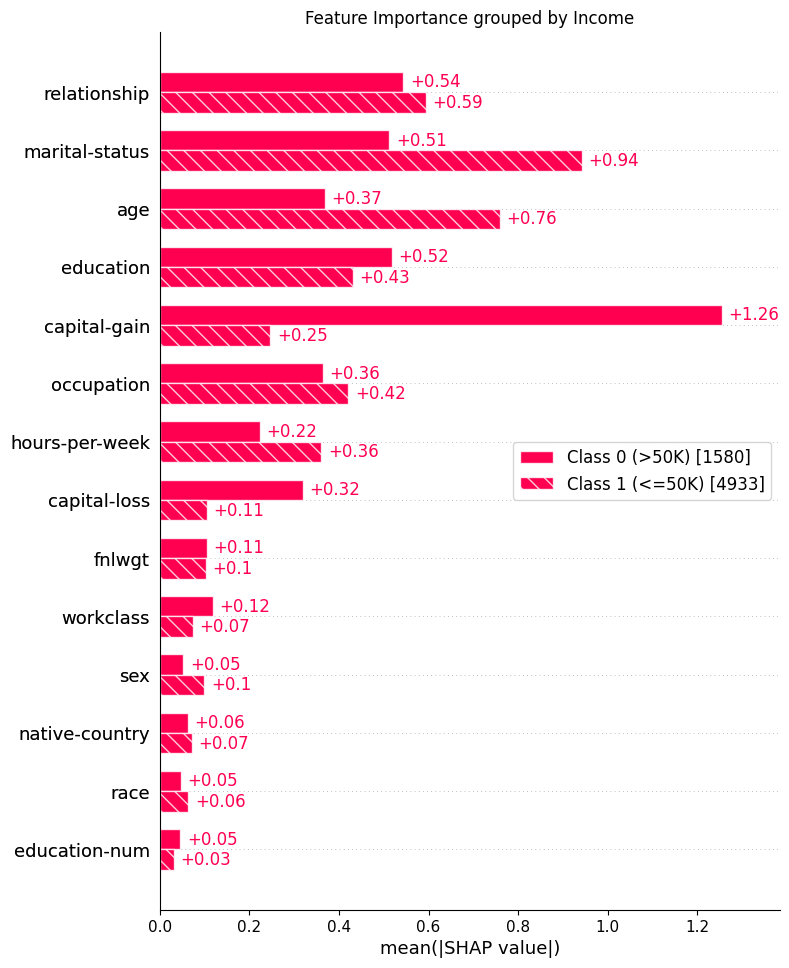

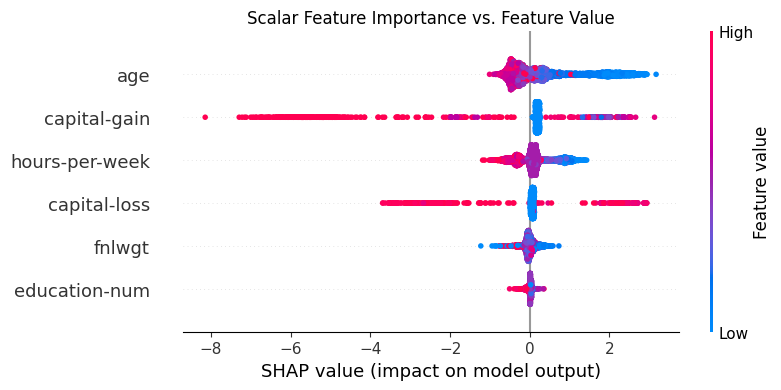

In [79]:
import matplotlib.pyplot as plt
import shap
import numpy as np

# https://www.geeksforgeeks.org/machine-learning/shap-a-comprehensive-guide-to-shapley-additive-explanations/

explainer = shap.Explainer(xgb_clf)
explanation = explainer(X_test)
#shap.summary_plot(shap_values, X_test, plot_type="bar") THIS style is actually outdated

y_flat = np.asarray(y_test).ravel()

cohorts = {
    "Class 0 (>50K)": explanation[y_flat == 0],
    "Class 1 (<=50K)": explanation[y_flat == 1],
}

ax = shap.plots.bar(cohorts, max_display=20, show=False)
ax.set_title("Feature Importance grouped by Income")
plt.show()

#print(explanation.feature_names)

explanation_scalars_only = explanation[:, ['age', 'capital-gain', 'hours-per-week', 'capital-loss', 'fnlwgt', 'education-num']]

ax = shap.plots.beeswarm(explanation_scalars_only, max_display=20, show=False)
ax.set_title("Scalar Feature Importance vs. Feature Value")
plt.show()


## As a member of the UVW marketing team, I want to know if the individuals who meet/don’t meet the target income level are similar or dissimilar between each other.

In [80]:
from sklearn.manifold import TSNE

# takes a long time so only run once
X_tsne = TSNE(n_components=2, random_state=420).fit_transform(dummies_X_test)

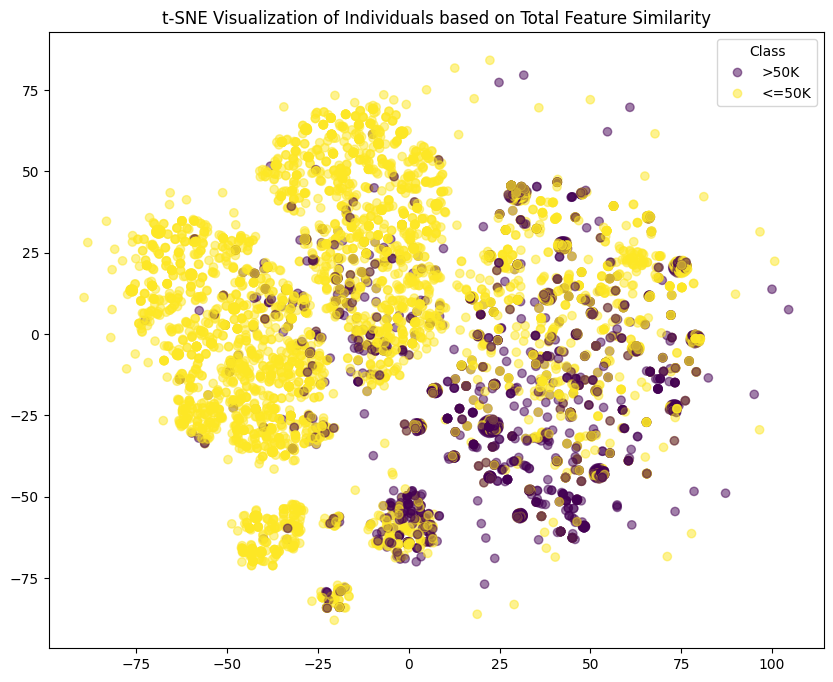

In [81]:
plt.figure(figsize=(10, 8))
ax = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_flat, alpha=0.5)
handles, labels = ax.legend_elements()
plt.legend(handles, ['>50K', '<=50K'], title="Class")
plt.title("t-SNE Visualization of Individuals based on Total Feature Similarity")
plt.show()

## As a future developer of this project, I want to know if there are any relationships between values of categorical features of the data set.

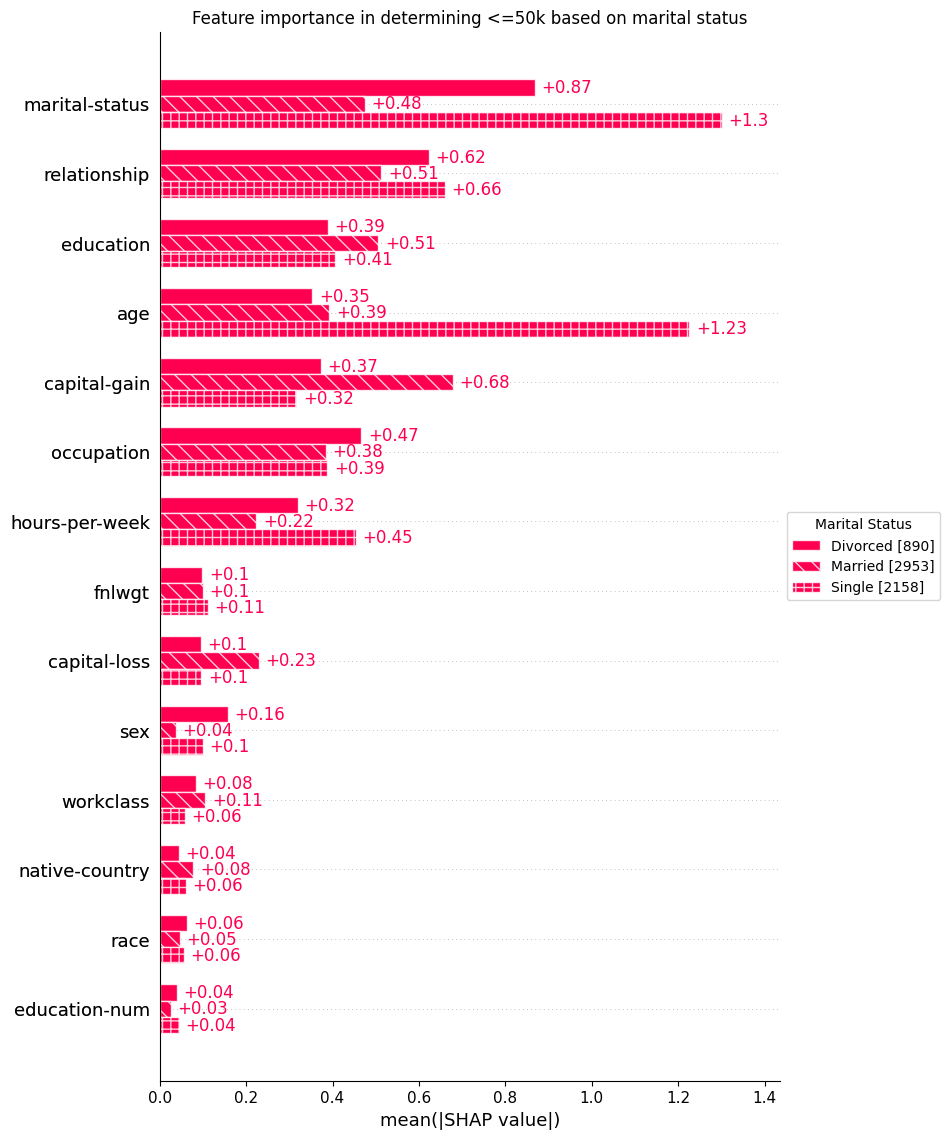

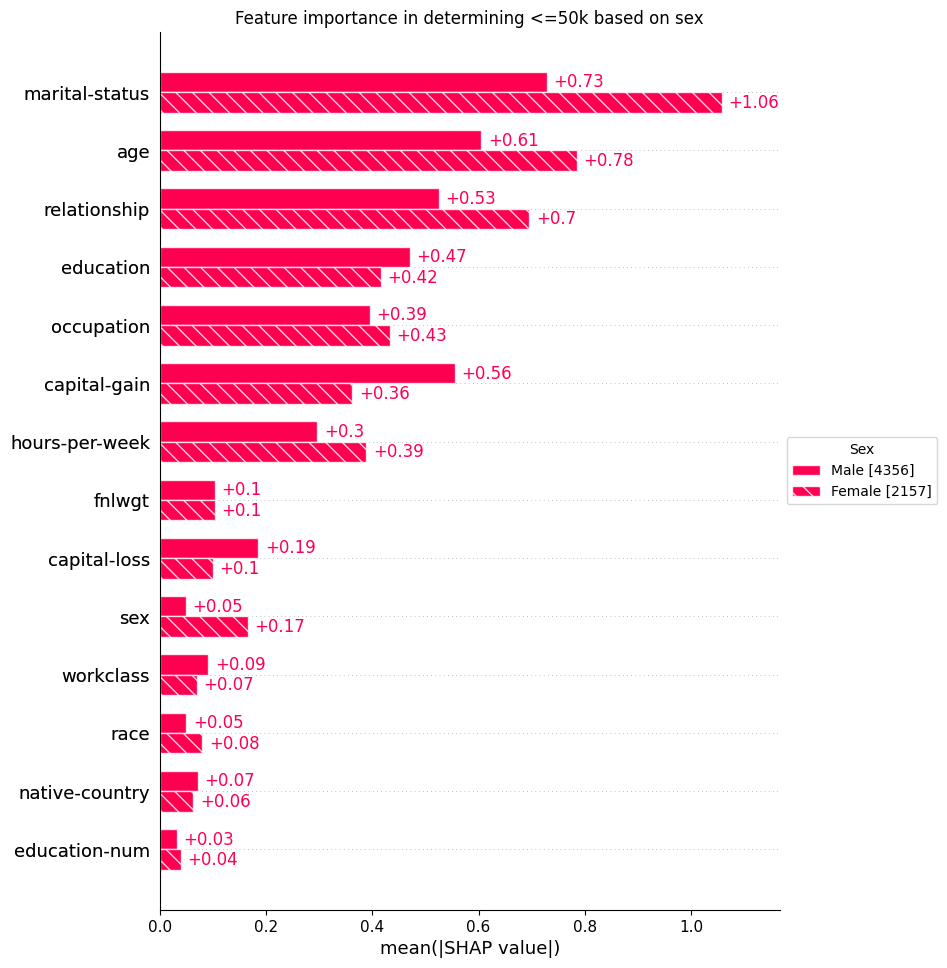

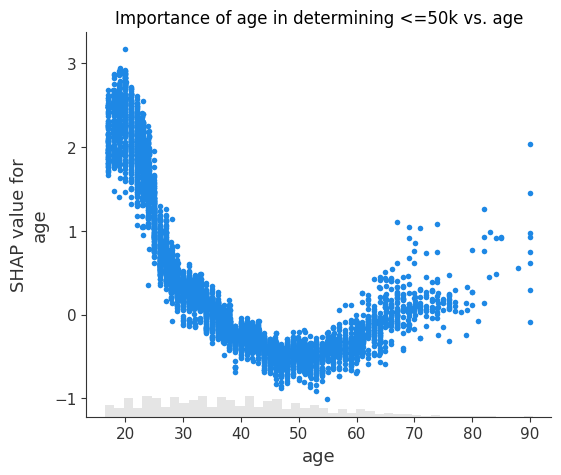

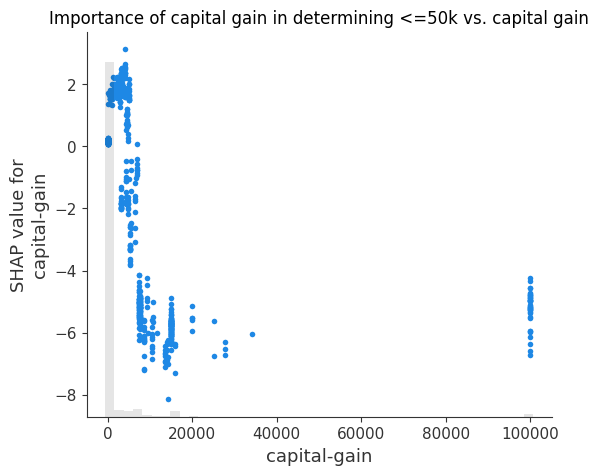

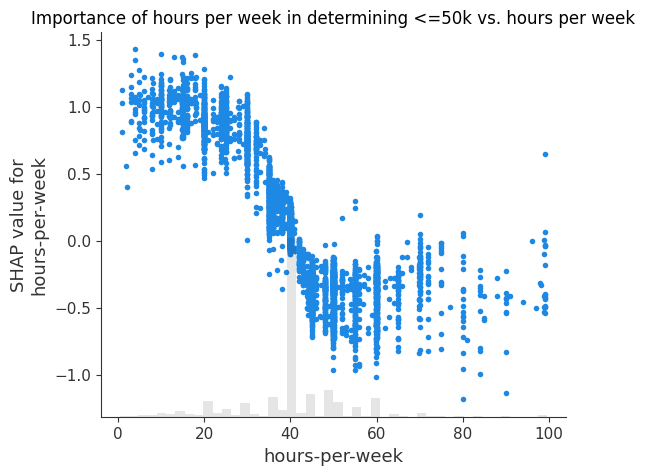

In [82]:
marital_status = np.asarray(X_test['marital-status'])

cohort = {
    'Divorced' : explanation[marital_status == 'Divorced'],
    'Married' : explanation[marital_status == 'Married-civ-spouse'],
    'Single' : explanation[marital_status == 'Never-married'],
}

ax = shap.plots.bar(cohort, max_display=20, show=False)
ax.set_title("Feature importance in determining <=50k based on marital status")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Marital Status")
plt.show()

#print(X_test['sex'].unique())

sex = np.asarray(X_test['sex'])

cohort = {
    'Male' : explanation[sex == 'Male'],
    'Female' : explanation[sex == 'Female']
}

ax = shap.plots.bar(cohort, max_display=20, show=False)
ax.set_title("Feature importance in determining <=50k based on sex")
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Sex")
plt.show()

ax = shap.plots.scatter(explanation[:, 'age'], show=False)
ax.set_title("Importance of age in determining <=50k vs. age")
plt.show()

ax = shap.plots.scatter(explanation[:, 'capital-gain'], show=False)
ax.set_title("Importance of capital gain in determining <=50k vs. capital gain")
plt.show()

ax = shap.plots.scatter(explanation[:, 'hours-per-week'], show=False)
ax.set_title("Importance of hours per week in determining <=50k vs. hours per week")
plt.show()

## As a member of the UVW marketing team, I want to view the relationships of the top factors in determining an individual’s income level. For example, gender vs. income.

C:\Users\pinkq\AppData\Local\Temp\ipykernel_32\2498710025.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_sex = df.groupby(['sex', 'class']).size().unstack()


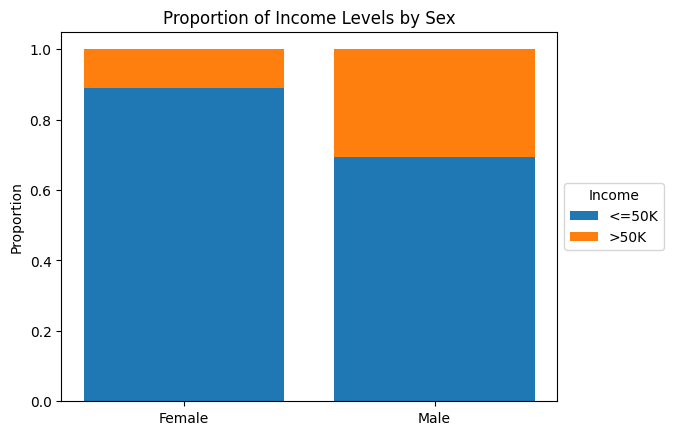

In [83]:
counts_sex = df.groupby(['sex', 'class']).size().unstack()
proportion = counts_sex.div(counts_sex.sum(axis=1), axis=0)
x = np.arange(len(proportion.index))

plt.bar(x, proportion['<=50K'], label='<=50K')
plt.bar(x, proportion['>50K'], bottom=proportion['<=50K'], label='>50K')
plt.xticks(x, proportion.index)
plt.ylabel("Proportion")
plt.title("Proportion of Income Levels by Sex")
plt.legend(title="Income", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()


C:\Users\pinkq\AppData\Local\Temp\ipykernel_32\3666802306.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_education = df.groupby(['education', 'class']).size().unstack()


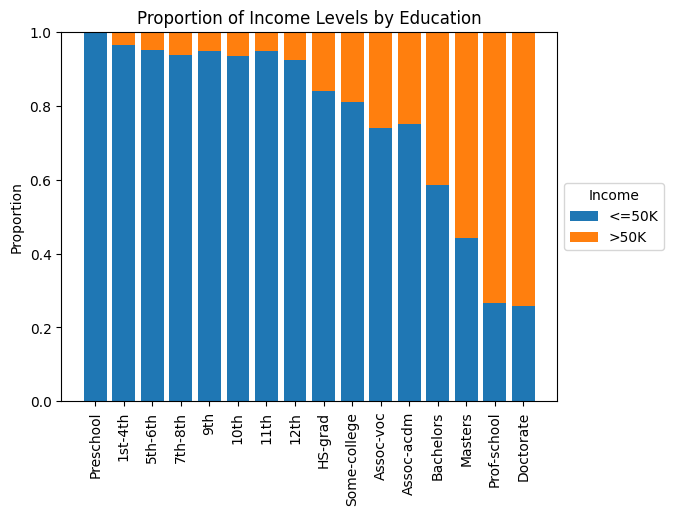

In [107]:
education_order = ['Preschool','1st-4th','5th-6th','7th-8th','9th','10th','11th','12th','HS-grad','Some-college','Assoc-voc','Assoc-acdm','Bachelors','Masters','Prof-school','Doctorate']
counts_education = df.groupby(['education', 'class']).size().unstack()
proportion_education = counts_education.div(counts_education.sum(axis=1), axis=0).loc[education_order]
x = np.arange(len(proportion_education.index))

plt.bar(x, proportion_education['<=50K'], label='<=50K')
plt.bar(x, proportion_education['>50K'], bottom=proportion_education['<=50K'], label='>50K')
plt.xticks(x, proportion_education.index, rotation=90)
plt.ylabel("Proportion")
plt.title("Proportion of Income Levels by Education")
plt.legend(title="Income", loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

C:\Users\pinkq\AppData\Local\Temp\ipykernel_32\1517670401.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts_occupation = df.groupby(['occupation', 'class']).size().unstack()


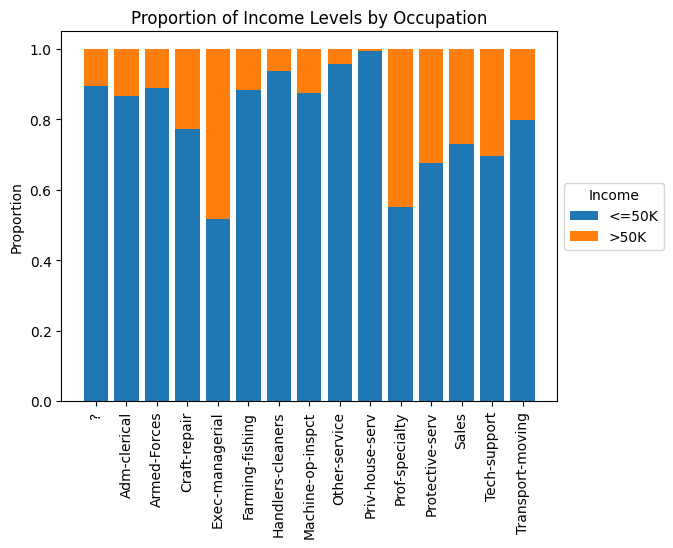

In [106]:
#print(df['occupation'].unique())

counts_occupation = df.groupby(['occupation', 'class']).size().unstack()
proportion_occupation = counts_occupation.div(counts_occupation.sum(axis=1), axis=0)
x = np.arange(len(proportion_occupation.index))

plt.bar(x, proportion_occupation['<=50K'], label='<=50K')
plt.bar(x, proportion_occupation['>50K'], bottom=proportion_occupation['<=50K'], label='>50K')
plt.xticks(x, proportion_occupation.index, rotation=90)
plt.ylabel("Proportion")
plt.title("Proportion of Income Levels by Occupation")
plt.legend(title="Income", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

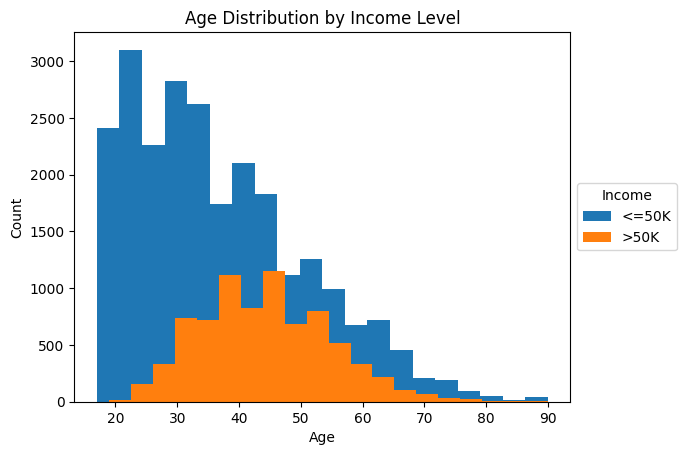

In [85]:
age_less50 = df[df['class'] == '<=50K']['age']
age_more50 = df[df['class'] == '>50K']['age']

plt.hist(age_less50, bins=20, label='<=50K')
plt.hist(age_more50, bins=20, label='>50K')
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution by Income Level")
plt.legend(title="Income", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


## As a member of the UVW marketing team, I want to construct the most typical individual who meets the target income level.

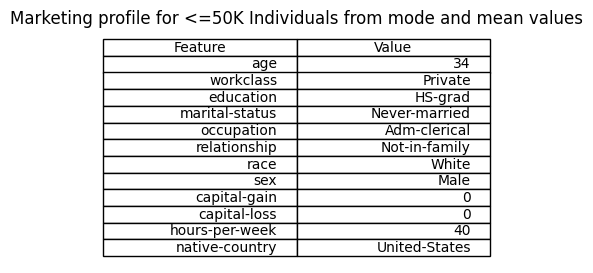

In [ ]:
marketing_profile = {}

for feature in df.columns:
    if feature in ['class', 'fnlwgt', 'education-num']:
        continue
    if df[feature].dtype.name == 'category':
        marketing_profile[feature] = df[df['class'] == '<=50K'][feature].mode()[0]
    else:
        marketing_profile[feature] = round(df[df['class'] == '<=50K'][feature].median())

#print(marketing_profile)

cell_text = [[k, v] for k, v in marketing_profile.items()]
plt.figure(figsize=(5, 3))
plt.axis('off')
plt.table(cellText=cell_text, colLabels=['Feature', 'Value'], loc='center')
plt.title("Marketing profile for <=50K Individuals from mode and median values")
plt.show()

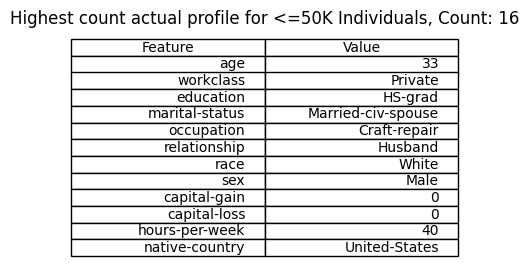

In [102]:
limited_features = ['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']

highest_count_profiles = (df[df['class'] == '<=50K'][limited_features]).value_counts()

highest_count_profile = highest_count_profiles.idxmax()

cell_text = [[k, v] for k, v in zip(limited_features, highest_count_profile)]
plt.figure(figsize=(5, 3))
plt.axis('off')
plt.table(cellText=cell_text, colLabels=['Feature', 'Value'], loc='center')
plt.title("Highest count actual profile for <=50K Individuals, Count: " + str(highest_count_profiles.iloc[0]))
plt.show()